<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/neat-POC/POC/neat/neat_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEAT for trading

Using another reinforcement framework for trading.

https://neat-python.readthedocs.io/en/latest/

In [42]:
# Colab setup
import sys
import os

if 'google.colab' in sys.modules:
    from google.colab import userdata
    !pip install -q neat-python
    %cd /content/
    repo = "Laksegate-master-thesis"
    branch = "neat-POC" # Change to "main" if necessary
    # remove local directory if it already exists
    if os.path.isdir(repo):
        !rm -rf {repo}
    !git clone -b {branch} https://github.com/Maziger/{repo}.git
    %cd Laksegate-master-thesis/POC/neat/

/content
Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 459, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 459 (delta 63), reused 62 (delta 25), pack-reused 306 (from 2)
Receiving objects: 100% (459/459), 57.03 MiB | 21.13 MiB/s, done.
Resolving deltas: 100% (232/232), done.
Updating files: 100% (250/250), done.
/content/Laksegate-master-thesis/POC/neat


## Mnimal example

In [ ]:
file_content = """[NEAT]
fitness_criterion     = max
fitness_threshold     = 3.9
pop_size              = 150
reset_on_extinction   = False
no_fitness_termination = False

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.01
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.2
node_delete_prob        = 0.2

num_hidden              = 0
num_inputs              = 2
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type      = gaussian
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type        = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-xor"

with open(file_name, "w") as f:
    f.write(file_content)

print(f"File '{file_name}' created successfully.")

File 'config-xor' created successfully.


In [ ]:
import neat

# XOR test cases: input -> expected output
xor_inputs = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
xor_outputs = [(0.0,),    (1.0,),    (1.0,),    (0.0,)]

def eval_genomes(genomes, config):
    """Fitness function: evaluates how well each genome solves XOR."""
    for genome_id, genome in genomes:
        # Create a neural network from this genome
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        # Start with perfect fitness, subtract error
        genome.fitness = 4.0

        # Test on all 4 XOR cases
        for xi, xo in zip(xor_inputs, xor_outputs):
            output = net.activate(xi)
            genome.fitness -= (output[0] - xo[0]) ** 2

# Load configuration
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                     neat.DefaultSpeciesSet, neat.DefaultStagnation,
                     'config-xor')

# Create population
p = neat.Population(config)
p.add_reporter(neat.StdOutReporter(True))

# Run evolution for up to 300 generations
winner = p.run(eval_genomes, 300)

# Test the winner
print('\nBest genome:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Population's average fitness: 2.28333 stdev: 0.36172
Best fitness: 2.98560 - size: (1, 2) - species 1 - id 124
Average adjusted fitness: 0.641
Mean genetic distance 1.392, standard deviation 0.467
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   150      2.986    0.641     0
Total extinctions: 0
Generation time: 0.015 sec

 ****** Running generation 1 ****** 

Population's average fitness: 2.37293 stdev: 0.35557
Best fitness: 2.99956 - size: (1, 2) - species 1 - id 236
Average adjusted fitness: 0.622
Mean genetic distance 1.323, standard deviation 0.466
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   150      3.000    0.622     0
Total extinctions: 0
Generation time: 0.021 sec (0.018 average)

 ****** Running generation 2 

# Trading algorithm
Develop a NEAT-based stock trading agent. This involves preprocessing the `msft_data` to create suitable features, adapting the NEAT configuration to a trading problem, implementing a custom fitness function that simulates trading and calculates profit/loss, executing the NEAT evolution to train the agent, and finally analyzing and visualizing the performance of the best trading agent.

## Preprocess Stock Data

### Subtask:
Transform the downloaded `msft_data` into a format suitable for the NEAT network. This step will involve creating relevant technical indicators or features (e.g., daily returns, moving averages, RSI, MACD) from the raw stock prices. You may also need to normalize these features to a common scale. The goal is to create input vectors for the NEAT network, representing market conditions, and corresponding expected outcomes (e.g., buy, sell, hold decisions) if you're using supervised learning, or just input for reinforcement learning.


In [6]:
import yfinance as yf

# Download Microsoft stock data
msft_data = yf.download("MSFT", start="2022-01-01", end="2024-12-31")

# Display the first few rows of the data
print(msft_data.head())

/tmp/ipython-input-148/1793568705.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft_data = yf.download("MSFT", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2022-01-03  323.160736  326.298219  318.362800  323.739970  28865100
2022-01-04  317.619537  323.595239  314.829576  323.238024  32674300
2022-01-05  305.426727  314.781256  305.040581  314.578505  40054300
2022-01-06  303.013245  307.666380  300.705974  302.308507  39646100
2022-01-07  303.167786  305.542611  299.354525  303.273963  32720000


In [13]:
# Install TA-Lib if not already installed
!pip install -q ta-lib
import talib

# Correctly access the 'Close' price from the MultiIndex DataFrame
# The structure from yfinance.download with auto_adjust=False results in ('Close', 'MSFT')
close_prices = msft_data[('Close', 'MSFT')]

msft_data['Daily Return'] = close_prices.pct_change()
msft_data['SMA_5'] = close_prices.rolling(window=5).mean()
msft_data['SMA_20'] = close_prices.rolling(window=20).mean()
msft_data['RSI'] = talib.RSI(close_prices, timeperiod=14)

print("Calculated Daily Return, SMA_5, SMA_20, and RSI.")
print(msft_data.head())

Calculated Daily Return, SMA_5, SMA_20, and RSI.
Price            Close        High         Low        Open    Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT   
Date                                                                   
2022-01-03  323.160736  326.298219  318.362800  323.739970  28865100   
2022-01-04  317.619537  323.595239  314.829576  323.238024  32674300   
2022-01-05  305.426727  314.781256  305.040581  314.578505  40054300   
2022-01-06  303.013245  307.666380  300.705974  302.308507  39646100   
2022-01-07  303.167786  305.542611  299.354525  303.273963  32720000   

Price      Daily Return       SMA_5 SMA_20 RSI  
Ticker                                          
Date                                            
2022-01-03          NaN         NaN    NaN NaN  
2022-01-04    -0.017147         NaN    NaN NaN  
2022-01-05    -0.038388         NaN    NaN NaN  
2022-01-06    -0.007902         NaN    NaN NaN  
2022-01-07     0.000510  310.47

In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create a new DataFrame with the required features, including RSI
trading_features = msft_data[['Daily Return', 'SMA_5', 'SMA_20', 'RSI']].copy()

# Handle NaN values by dropping the corresponding rows
trading_features.dropna(inplace=True);

# Initialize MinMaxScaler
scaler = MinMaxScaler();

# Fit and transform the trading features
normalized_trading_features = pd.DataFrame(scaler.fit_transform(trading_features),
                                           columns=trading_features.columns,
                                           index=trading_features.index);

print("Trading features created, NaN values dropped, and features normalized.")
print(normalized_trading_features.head())

Trading features created, NaN values dropped, and features normalized.
Price      Daily Return     SMA_5    SMA_20       RSI
Ticker                                               
Date                                                 
2022-01-31     0.539315  0.307582  0.325658  0.295005
2022-02-01     0.439190  0.323766  0.320031  0.269136
2022-02-02     0.579451  0.337140  0.316664  0.350837
2022-02-03     0.239637  0.338266  0.313388  0.214262
2022-02-04     0.581622  0.336414  0.311669  0.291278


In [15]:
num_inputs = normalized_trading_features.shape[1]
print(f"Number of input features for NEAT: {num_inputs}")

Number of input features for NEAT: 4


## Implement Trading Fitness Function

### Subtask:
Create a new `eval_genomes` function that simulates a trading strategy based on the NEAT network's output, calculates profit/loss, and assigns it as fitness.


In [19]:
import neat

def eval_genomes_trading(genomes, config):
    """Fitness function for trading: evaluates how well each genome performs a trading strategy."""
    global normalized_trading_features, msft_data # Access global dataframes

    # Align dataframes by index to ensure correct date-to-feature mapping
    # Only consider dates that are present in both dataframes after preprocessing
    common_index = normalized_trading_features.index.intersection(msft_data.index)
    trading_inputs = normalized_trading_features.loc[common_index]
    trading_prices = msft_data.loc[common_index, 'Close']

    # Ensure trading_inputs is not empty to avoid errors
    if trading_inputs.empty:
        for genome_id, genome in genomes:
            genome.fitness = 0.0
        return

    for genome_id, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        initial_cash = 10000.0
        cash = initial_cash
        shares_held = 0.0 # Initialize as float to be consistent with calculations

        buy_threshold = 0.6
        sell_threshold = 0.4

        for i in range(len(trading_inputs)):
            current_features = trading_inputs.iloc[i].values # Get features for current day
            current_price = trading_prices.iloc[i].item() # Get scalar closing price for current day

            output = net.activate(current_features)
            decision_signal = output[0] # Assuming 1 output

            if decision_signal > buy_threshold: # Buy signal
                if cash > 0: # Check if there is cash to buy
                    # Buy as many shares as possible with available cash
                    num_shares_to_buy = cash / current_price
                    shares_held += num_shares_to_buy
                    cash -= num_shares_to_buy * current_price

            elif decision_signal < sell_threshold: # Sell signal
                if shares_held > 0: # Check if there are shares to sell
                    # Sell all held shares
                    cash += shares_held * current_price
                    shares_held = 0.0 # Reset to float
            # Else: hold

        # Calculate final portfolio value
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1].item())

        # Assign fitness (maximize portfolio value)
        genome.fitness = final_portfolio_value

    print("Finished evaluating genomes with trading strategy.")

The below code also allows the agent to go short

In [ ]:
import neat

# Assuming initial_cash is defined globally or passed as an argument if needed for short-selling
# For simplicity, we'll use a fixed initial_cash value to determine short-sell amount.
initial_cash_for_short_sell_determination = 10000.0 # This can be tuned

def eval_genomes_trading(genomes, config):
    """Fitness function for trading: evaluates how well each genome performs a trading strategy with shorting capabilities."""
    global normalized_trading_features, msft_data # Access global dataframes

    # Align dataframes by index to ensure correct date-to-feature mapping
    # Only consider dates that are present in both dataframes after preprocessing
    common_index = normalized_trading_features.index.intersection(msft_data.index)
    trading_inputs = normalized_trading_features.loc[common_index]
    trading_prices = msft_data.loc[common_index, 'Close']

    # Ensure trading_inputs is not empty to avoid errors
    if trading_inputs.empty:
        for genome_id, genome in genomes:
            genome.fitness = 0.0
        return

    for genome_id, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        initial_cash = 10000.0
        cash = initial_cash
        shares_held = 0.0 # Can be positive (long) or negative (short)

        # New thresholds for short-selling and covering
        buy_cover_threshold = 0.7
        sell_short_threshold = 0.3

        for i in range(len(trading_inputs)):
            current_features = trading_inputs.iloc[i].values # Get features for current day
            current_price = trading_prices.iloc[i].item() # Get scalar closing price for current day

            output = net.activate(current_features)
            decision_signal = output[0] # Assuming 1 output, ranging from 0 to 1

            if decision_signal >= buy_cover_threshold: # Buy or Cover signal
                if shares_held < 0: # Agent is currently short, so cover
                    # Buy back all shares to cover the short position
                    cash -= abs(shares_held) * current_price # Cost to cover
                    shares_held = 0.0 # Position is now flat
                elif cash > 0: # Agent is holding cash or flat, so buy long
                    # Buy as many shares as possible with available cash
                    num_shares_to_buy = cash / current_price
                    shares_held += num_shares_to_buy
                    cash -= num_shares_to_buy * current_price # Cash is now used

            elif decision_signal <= sell_short_threshold: # Sell or Short signal
                if shares_held > 0: # Agent is currently long, so sell
                    # Sell all held shares
                    cash += shares_held * current_price
                    shares_held = 0.0 # Position is now flat
                elif cash > 0: # Agent is holding cash or flat, so short sell
                    # Short sell shares equivalent to a certain value (e.g., initial_cash)
                    # This adds cash to the account, and increases negative shares_held
                    num_shares_to_short = initial_cash_for_short_sell_determination / current_price # For simplicity, short sell based on initial cash value
                    cash += num_shares_to_short * current_price # Proceeds from short sell
                    shares_held -= num_shares_to_short # Shares held becomes negative

            # Else (sell_short_threshold < decision_signal < buy_cover_threshold): hold current position

        # Calculate final portfolio value, accounting for potential short positions
        # If shares_held is negative, it means we owe shares, and this is a liability.
        # If cash is negative after covering, this represents a loss that exceeds initial cash.
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1].item())

        # Assign fitness (maximize portfolio value)
        genome.fitness = final_portfolio_value

    print("Finished evaluating genomes with trading strategy.")

## Running the models

### Run 1 (base run)

Config file

In [35]:
trading_config_content = f"""[NEAT]
fitness_criterion     = max
fitness_threshold     = 50000.0
pop_size              = 150
reset_on_extinction   = False
no_fitness_termination = False

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.01
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.2
node_delete_prob        = 0.2

num_hidden              = 0
num_inputs              = {num_inputs}
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type          = gaussian
response_max_value          = 30.0
response_min_value          = -30.0
response_mutate_power       = 0.0
response_mutate_rate        = 0.0
response_replace_rate       = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type          = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-trading.txt"

with open(file_name, "w") as f:
    f.write(trading_config_content)

print(f"File '{file_name}' created successfully.")

File 'config-trading.txt' created successfully.


In [ ]:
import neat

# Load the NEAT configuration for trading
config_trading = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             'config-trading.txt')

# Create a NEAT population
p_trading = neat.Population(config_trading);

# Add a reporter to display progress in stdout
p_trading.add_reporter(neat.StdOutReporter(True))

# Run the evolution process with the custom trading fitness function
# We'll run for 50 generations as an initial test
winner = p_trading.run(eval_genomes_trading, 50)

# Print information about the best genome found
print('\nBest genome found:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Finished evaluating genomes with trading strategy.
Population's average fitness: 11889.62701 stdev: 1912.46979
Best fitness: 17136.28659 - size: (1, 3) - species 1 - id 131
Average adjusted fitness: 0.331
Mean genetic distance 1.204, standard deviation 0.401
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   150  17136.287    0.331     0
Total extinctions: 0
Generation time: 18.754 sec

 ****** Running generation 1 ****** 

Finished evaluating genomes with trading strategy.
Population's average fitness: 13308.15381 stdev: 1660.89897
Best fitness: 19657.72516 - size: (1, 3) - species 1 - id 191
Average adjusted fitness: 0.402
Mean genetic distance 1.524, standard deviation 0.434
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1  

### Run 2

In [49]:
trading_config_content = f"""[NEAT]
fitness_criterion     = max
fitness_threshold     = 500000.0
pop_size              = 200
reset_on_extinction   = False
no_fitness_termination = False
seed = 420

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.8
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.02
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.5
node_delete_prob        = 0.5

num_hidden              = 2
num_inputs              = {num_inputs}
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type          = gaussian
response_max_value          = 30.0
response_min_value          = -30.0
response_mutate_power       = 0.0
response_mutate_rate        = 0.0
response_replace_rate       = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type          = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 15
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-trading.txt"

with open(file_name, "w") as f:
    f.write(trading_config_content)

print(f"File '{file_name}' created successfully.")

File 'config-trading.txt' created successfully.


In [50]:
# Ability to short
import neat
import multiprocessing
# Load the NEAT configuration for trading
config_trading = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             'config-trading.txt')

# Create a NEAT population
p_trading = neat.Population(config_trading);

# Add a reporter to display progress in stdout
p_trading.add_reporter(neat.StdOutReporter(True))

# Run the evolution process with the custom trading fitness function
# We'll run for 50 generations as an initial test
with neat.ParallelEvaluator(multiprocessing.cpu_count(), eval_genomes_trading) as pe:
    winner = p_trading.run(eval_genomes_trading, 50)

# Print information about the best genome found
print('\nBest genome found:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Finished evaluating genomes with trading strategy.
Population's average fitness: -851103.69293 stdev: 1108891.17222
Best fitness: 34386.79498 - size: (3, 14) - species 2 - id 92
Average adjusted fitness: 0.674
Mean genetic distance 2.758, standard deviation 0.426
Population of 200 members in 14 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0     8  18764.106    0.920     0
     2    0    35  34386.795    0.884     0
     3    0    11  14015.306    0.441     0
     4    0    22  14015.306    0.990     0
     5    0     8  14297.773    0.284     0
     6    0    20  14015.306    0.977     0
     7    0    25  14304.697    0.924     0
     8    0    11  -385697.140    0.103     0
     9    0    13  14441.632    0.813     0
    10    0    13  17143.977    0.594     0
    11    0    14  14015.306    0.992     0
    12    0     6  14604.767    0.693     0
    13    0     3

In [38]:
import neat
import multiprocessing
# Load the NEAT configuration for trading
config_trading = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             'config-trading.txt')

# Create a NEAT population
p_trading = neat.Population(config_trading);

# Add a reporter to display progress in stdout
p_trading.add_reporter(neat.StdOutReporter(True))

# Run the evolution process with the custom trading fitness function
# We'll run for 50 generations as an initial test
with neat.ParallelEvaluator(multiprocessing.cpu_count(), eval_genomes_trading) as pe:
    winner = p_trading.run(eval_genomes_trading, 50)

# Print information about the best genome found
print('\nBest genome found:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Finished evaluating genomes with trading strategy.
Population's average fitness: 12075.50256 stdev: 1904.17532
Best fitness: 15963.36936 - size: (3, 14) - species 2 - id 12
Average adjusted fitness: 0.466
Mean genetic distance 2.764, standard deviation 0.424
Population of 200 members in 14 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    19  15235.805    0.646     0
     2    0    30  15963.369    0.599     0
     3    0     3  14015.306    0.218     0
     4    0    15  14297.773    0.671     0
     5    0    31  13727.455    0.178     0
     6    0    16  14015.306    0.645     0
     7    0    10  14467.983    0.532     0
     8    0    12  11973.071    0.191     0
     9    0    14  14441.632    0.399     0
    10    0    15  15236.883    0.476     0
    11    0    12  14015.306    0.717     0
    12    0     6  15156.624    0.481     0
    13    0     2  11425

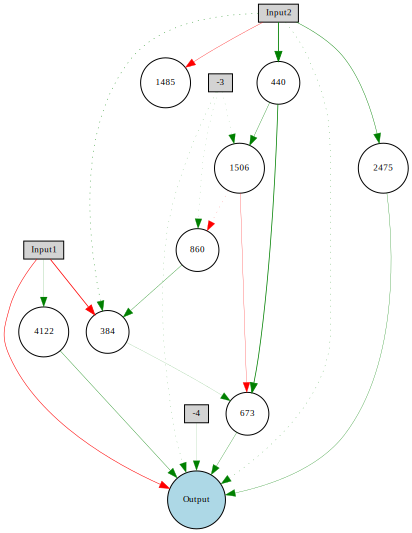

In [44]:
import visualize

visualize.draw_net(config_trading, winner, view=True,
                   node_names={-1: 'Input1', -2: 'Input2', 0: 'Output'})

## Analyze and Visualize Trading Agent Performance

### Subtask:
After the NEAT evolution concludes, analyze the performance of the 'winner' genome (the best trading agent found). This step should involve simulating its trading strategy on a separate test dataset (if you split your data) or the original dataset, and then visualizing the results. Useful visualizations include plotting the portfolio value over time, comparing the agent's performance against a benchmark (e.g., buy-and-hold), and displaying trade entry/exit points on a price chart. Ensure legends are provided for all visualizations.


**Reasoning**:
I need to simulate the trading strategy of the `winner` genome to gather its portfolio value over time and all the buy/sell actions. This function will be similar to `eval_genomes_trading` but will store detailed trading history for visualization.



In [52]:
import numpy as np

def simulate_trading_strategy(genome, config, normalized_features, raw_prices):
    """Simulates the trading strategy of a single genome and returns portfolio history and trade points."""
    net = neat.nn.FeedForwardNetwork.create(genome, config)

    initial_cash = 10000.0
    cash = initial_cash
    shares_held = 0.0

    buy_threshold = 0.6
    sell_threshold = 0.4

    portfolio_history = []
    buy_points = [] # List of (date, price) for buy actions
    sell_points = [] # List of (date, price) for sell actions

    # Ensure data is aligned and extract scalar prices
    common_index = normalized_features.index.intersection(raw_prices.index)
    trading_inputs = normalized_features.loc[common_index]
    trading_prices = raw_prices.loc[common_index] # Simplified to directly get the Series of prices

    if trading_inputs.empty:
        return [], [], []

    for i in range(len(trading_inputs)):
        current_features = trading_inputs.iloc[i].values
        current_price = trading_prices.iloc[i] # This will now be a scalar float
        current_date = trading_prices.index[i]

        output = net.activate(current_features)
        decision_signal = output[0]

        # Record current portfolio value before decision for the day
        current_portfolio_value = cash + (shares_held * current_price)
        portfolio_history.append((current_date, current_portfolio_value))

        if decision_signal > buy_threshold: # Buy signal
            if cash > 0:
                # Buy as many shares as possible with available cash
                num_shares_to_buy = cash / current_price
                shares_held += num_shares_to_buy
                cash = 0.0 # All cash spent
                buy_points.append((current_date, current_price))

        elif decision_signal < sell_threshold: # Sell signal
            if shares_held > 0:
                # Sell all held shares
                cash += shares_held * current_price
                shares_held = 0.0 # All shares sold
                sell_points.append((current_date, current_price))
        # Else: hold

    # Add final portfolio value if the loop ended without recording it
    if not portfolio_history or portfolio_history[-1][0] != trading_prices.index[-1]:
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1])
        portfolio_history.append((trading_prices.index[-1], final_portfolio_value))

    return portfolio_history, buy_points, sell_points

print("Defined `simulate_trading_strategy` function.")

Defined `simulate_trading_strategy` function.


In [55]:
import numpy as np

def simulate_trading_strategy(genome, config, normalized_features, raw_prices):
    """Simulates the trading strategy of a single genome and returns portfolio history and trade points with shorting capabilities."""
    net = neat.nn.FeedForwardNetwork.create(genome, config)

    initial_cash = 10000.0
    cash = initial_cash
    shares_held = 0.0 # Can be positive (long) or negative (short)

    # New thresholds for short-selling and covering
    buy_cover_threshold = 0.7
    sell_short_threshold = 0.3

    # For simplicity, use a fixed value to determine short-sell amount (similar to eval_genomes_trading)
    initial_cash_for_short_sell_determination = 10000.0

    portfolio_history = []
    buy_points = [] # List of (date, price) for buy actions (long or cover short)
    sell_points = [] # List of (date, price) for sell actions (long or short sell)

    # Ensure data is aligned and extract scalar prices
    common_index = normalized_features.index.intersection(raw_prices.index)
    trading_inputs = normalized_features.loc[common_index]
    trading_prices = raw_prices.loc[common_index] # This is already a Series of prices

    if trading_inputs.empty:
        return [], [], []

    for i in range(len(trading_inputs)):
        current_features = trading_inputs.iloc[i].values
        current_price = trading_prices.iloc[i] # This will now be a scalar float
        current_date = trading_prices.index[i]

        # Record current portfolio value before decision for the day
        # This ensures the portfolio value includes the stock's current price
        current_portfolio_value = cash + (shares_held * current_price)
        portfolio_history.append((current_date, current_portfolio_value))

        output = net.activate(current_features)
        decision_signal = output[0]

        if decision_signal >= buy_cover_threshold: # Buy or Cover signal
            if shares_held < 0: # Agent is currently short, so cover
                # Buy back all shares to cover the short position
                cash -= abs(shares_held) * current_price # Cost to cover
                shares_held = 0.0 # Position is now flat
                buy_points.append((current_date, current_price)) # Mark as a buy to cover
            elif cash > 0: # Agent is holding cash or flat, so buy long
                # Buy as many shares as possible with available cash
                num_shares_to_buy = cash / current_price
                shares_held += num_shares_to_buy
                cash = 0.0 # All cash spent
                buy_points.append((current_date, current_price))

        elif decision_signal <= sell_short_threshold: # Sell or Short signal
            if shares_held > 0: # Agent is currently long, so sell
                # Sell all held shares
                cash += shares_held * current_price
                shares_held = 0.0 # Position is now flat
                sell_points.append((current_date, current_price))
            #elif cash > 0: # Agent is holding cash or flat, so short sell
            # Changed condition to allow short selling even with no cash, just like normal shorting in eval_genomes_trading
            elif shares_held >= 0: # If not currently long, can initiate short sell
                # Short sell shares equivalent to a certain value (e.g., initial_cash_for_short_sell_determination)
                num_shares_to_short = initial_cash_for_short_sell_determination / current_price
                cash += num_shares_to_short * current_price # Proceeds from short sell
                shares_held -= num_shares_to_short # Shares held becomes negative
                sell_points.append((current_date, current_price)) # Mark as a short sell

        # Else (sell_short_threshold < decision_signal < buy_cover_threshold): hold current position

    # Add final portfolio value if the loop ended without recording it on the last day
    # This is to ensure the very last day's value is always captured, even if no trade happened.
    if not portfolio_history or portfolio_history[-1][0] != trading_prices.index[-1]:
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1])
        portfolio_history.append((trading_prices.index[-1], final_portfolio_value))

    return portfolio_history, buy_points, sell_points

print("Defined `simulate_trading_strategy` function with shorting capabilities.")

Defined `simulate_trading_strategy` function with shorting capabilities.


**Reasoning**:
Now that the `simulate_trading_strategy` function has been corrected, I will re-run the simulation for the `winner` genome and calculate the buy-and-hold strategy for comparison. This will generate the necessary data for the visualization steps.



In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-run the trading simulation using the winner genome
portfolio_history_data, buy_points, sell_points = simulate_trading_strategy(winner, config_trading, normalized_trading_features, msft_data[('Close', 'MSFT')])

# Convert portfolio history to DataFrame for easier plotting
portfolio_df = pd.DataFrame(portfolio_history_data, columns=['Date', 'Portfolio Value'])
portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'])
portfolio_df.set_index('Date', inplace=True)

# Convert buy/sell points to DataFrames
buy_points_df = pd.DataFrame(buy_points, columns=['Date', 'Price'])
buy_points_df['Date'] = pd.to_datetime(buy_points_df['Date'])
buy_points_df.set_index('Date', inplace=True)

sell_points_df = pd.DataFrame(sell_points, columns=['Date', 'Price'])
sell_points_df['Date'] = pd.to_datetime(sell_points_df['Date'])
sell_points_df.set_index('Date', inplace=True)

# 2. Calculate the performance of a simple buy-and-hold strategy
initial_cash_bh = 10000.0
# Get the first available closing price after features are calculated
first_price_bh = msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[0]].item()
last_price_bh = msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[-1]].item()

# Number of shares bought at the beginning
shares_bought_bh = initial_cash_bh / first_price_bh

# Portfolio value over time for buy-and-hold
buy_and_hold_portfolio_values = (msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[0]:normalized_trading_features.index[-1]] / first_price_bh) * initial_cash_bh
buy_and_hold_portfolio_df = pd.DataFrame({'Portfolio Value': buy_and_hold_portfolio_values})

print("Simulation and buy-and-hold calculation complete.")

Simulation and buy-and-hold calculation complete.


**Reasoning**:
I have successfully run the simulation and calculated the buy-and-hold strategy. Now, I will plot the portfolio values of both the NEAT agent and the buy-and-hold strategy over time to compare their performance, as requested by the instructions.



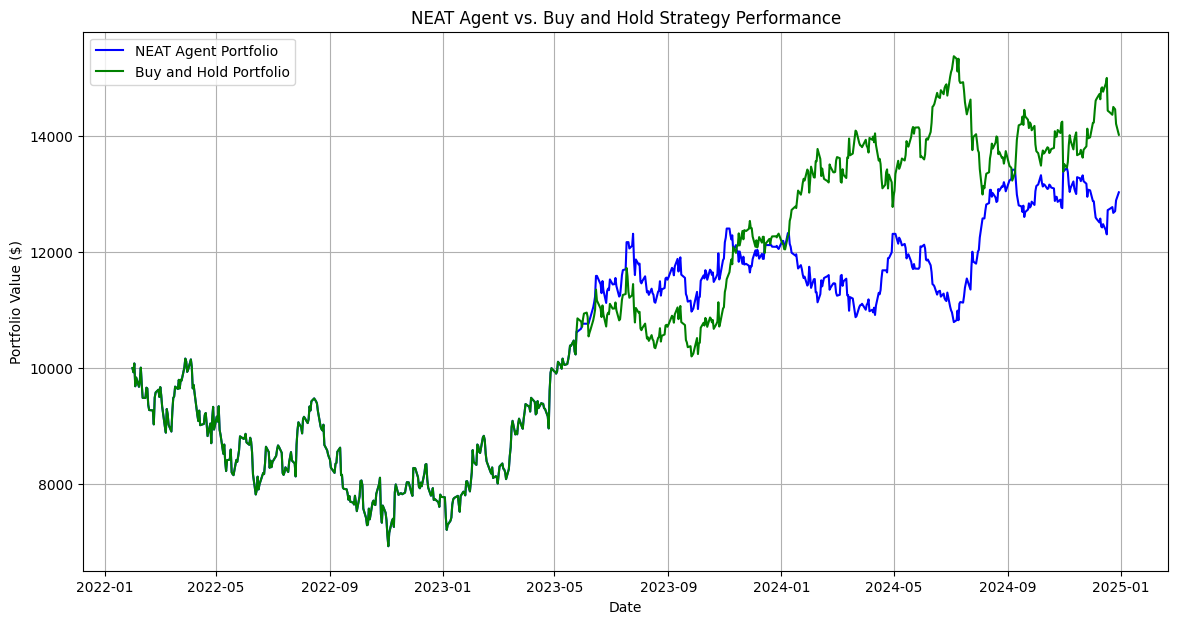

Portfolio comparison plot generated.


In [57]:
plt.figure(figsize=(14, 7))
plt.plot(portfolio_df.index, portfolio_df['Portfolio Value'], label='NEAT Agent Portfolio', color='blue')
plt.plot(buy_and_hold_portfolio_df.index, buy_and_hold_portfolio_df['Portfolio Value'], label='Buy and Hold Portfolio', color='green')
plt.title('NEAT Agent vs. Buy and Hold Strategy Performance')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Portfolio comparison plot generated.")

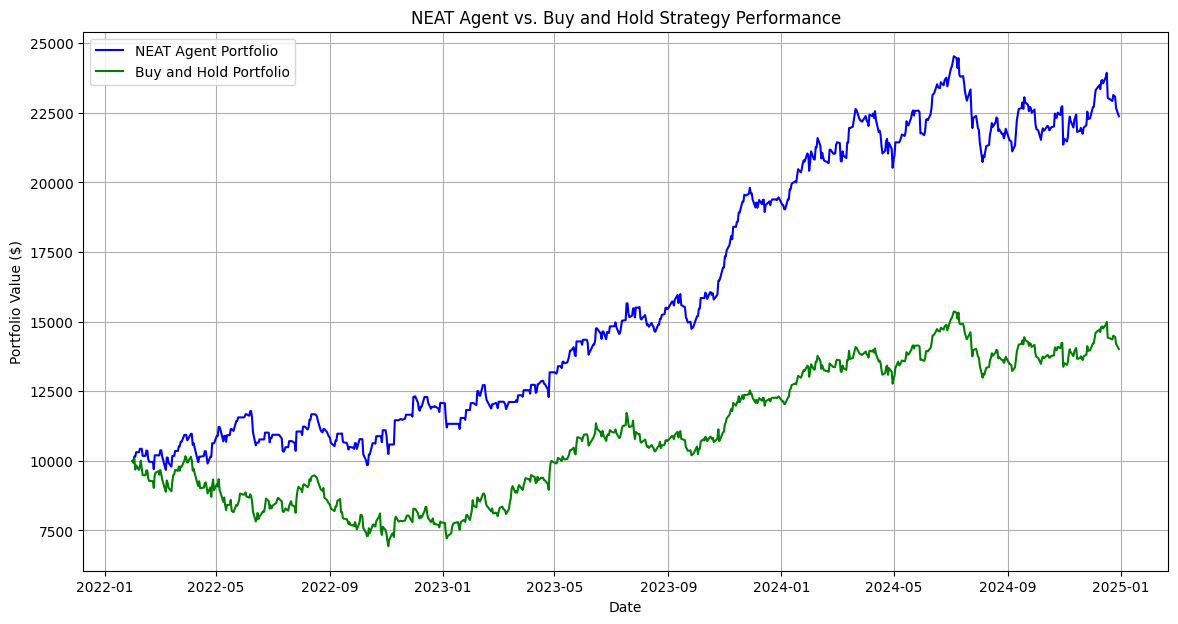

Portfolio comparison plot generated.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(portfolio_df.index, portfolio_df['Portfolio Value'], label='NEAT Agent Portfolio', color='blue')
plt.plot(buy_and_hold_portfolio_df.index, buy_and_hold_portfolio_df['Portfolio Value'], label='Buy and Hold Portfolio', color='green')
plt.title('NEAT Agent vs. Buy and Hold Strategy Performance')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Portfolio comparison plot generated.")

**Reasoning**:
I have plotted the portfolio values. Now, I will create a separate plot to visualize the stock's closing price over time, marking the specific dates where the NEAT agent made buy and sell decisions, as requested by the instructions.



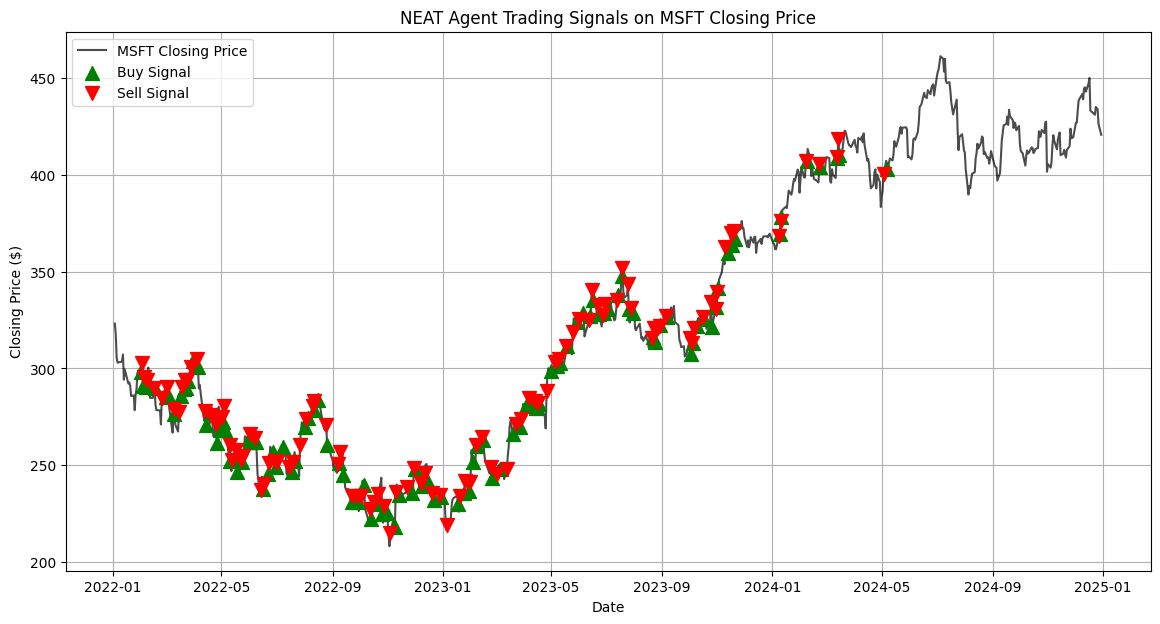

Trading signals plot generated.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(msft_data.index, msft_data[('Close', 'MSFT')], label='MSFT Closing Price', color='black', alpha=0.7)
plt.scatter(buy_points_df.index, buy_points_df['Price'], marker='^', color='green', s=100, label='Buy Signal', zorder=5)
plt.scatter(sell_points_df.index, sell_points_df['Price'], marker='v', color='red', s=100, label='Sell Signal', zorder=5)
plt.title('NEAT Agent Trading Signals on MSFT Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Trading signals plot generated.")

## Final Task

### Subtask:
Summarize the findings from the NEAT trading agent development, including insights into its performance and potential next steps for improvement or further analysis.


## Validation

In [59]:
import yfinance as yf

# Download Microsoft stock data
msft_data_test = yf.download("MSFT", start="2025-01-01", end="2025-03-31")

# Display the first few rows of the data
print(msft_data_test.head())

/tmp/ipython-input-148/3834458121.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft_data_test = yf.download("MSFT", start="2025-01-01", end="2025-03-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2025-01-02  414.568604  421.986845  410.874369  421.452012  16896500
2025-01-03  419.292908  419.966384  415.519423  417.044643  16662900
2025-01-06  423.749786  430.157784  421.402504  423.898343  20573600
2025-01-07  418.322266  426.522914  416.767304  424.888733  18139100
2025-01-08  420.491302  422.878210  417.500255  419.401838  15054600


In [60]:
msft_data_test['Daily Return'] = msft_data_test['Close'].pct_change()
msft_data_test['SMA_5'] = msft_data_test['Close'].rolling(window=5).mean()
msft_data_test['SMA_20'] = msft_data_test['Close'].rolling(window=20).mean()

print("Calculated Daily Return, SMA_5, and SMA_20.")
print(msft_data_test.head())

Calculated Daily Return, SMA_5, and SMA_20.
Price            Close        High         Low        Open    Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT   
Date                                                                   
2025-01-02  414.568604  421.986845  410.874369  421.452012  16896500   
2025-01-03  419.292908  419.966384  415.519423  417.044643  16662900   
2025-01-06  423.749786  430.157784  421.402504  423.898343  20573600   
2025-01-07  418.322266  426.522914  416.767304  424.888733  18139100   
2025-01-08  420.491302  422.878210  417.500255  419.401838  15054600   

Price      Daily Return       SMA_5 SMA_20  
Ticker                                      
Date                                        
2025-01-02          NaN         NaN    NaN  
2025-01-03     0.011396         NaN    NaN  
2025-01-06     0.010630         NaN    NaN  
2025-01-07    -0.012808         NaN    NaN  
2025-01-08     0.005185  419.284973    NaN  


In [61]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create a new DataFrame with the required features
trading_features = msft_data_test[['Daily Return', 'SMA_5', 'SMA_20']].copy()

# Handle NaN values by dropping the corresponding rows
trading_features.dropna(inplace=True)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the trading features
normalized_trading_features = pd.DataFrame(scaler.fit_transform(trading_features),
                                           columns=trading_features.columns,
                                           index=trading_features.index)

print("Trading features created, NaN values dropped, and features normalized.")
print(normalized_trading_features.head())

Trading features created, NaN values dropped, and features normalized.
Price      Daily Return     SMA_5    SMA_20
Ticker                                     
Date                                       
2025-01-31     0.514054  1.000000  1.000000
2025-02-03     0.358885  0.901128  0.990270
2025-02-04     0.565453  0.755456  0.976322
2025-02-05     0.545604  0.633999  0.957826
2025-02-06     0.605120  0.637471  0.949506


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-run the trading simulation using the winner genome on test data
portfolio_history_data_test, buy_points_test, sell_points_test = simulate_trading_strategy(winner, config_trading, normalized_trading_features, msft_data_test[('Close', 'MSFT')])

# Convert portfolio history to DataFrame for easier plotting
portfolio_df_test = pd.DataFrame(portfolio_history_data_test, columns=['Date', 'Portfolio Value'])
portfolio_df_test['Date'] = pd.to_datetime(portfolio_df_test['Date'])
portfolio_df_test.set_index('Date', inplace=True)

# Convert buy/sell points to DataFrames
buy_points_df_test = pd.DataFrame(buy_points_test, columns=['Date', 'Price'])
buy_points_df_test['Date'] = pd.to_datetime(buy_points_df_test['Date'])
buy_points_df_test.set_index('Date', inplace=True)

sell_points_df_test = pd.DataFrame(sell_points_test, columns=['Date', 'Price'])
sell_points_df_test['Date'] = pd.to_datetime(sell_points_df_test['Date'])
sell_points_df_test.set_index('Date', inplace=True)

# 2. Calculate the performance of a simple buy-and-hold strategy for test data
initial_cash_bh_test = 10000.0
# Get the first available closing price after features are calculated for test data
first_price_bh_test = msft_data_test[('Close', 'MSFT')].loc[normalized_trading_features.index[0]].item()
# Portfolio value over time for buy-and-hold for test data
buy_and_hold_portfolio_values_test = (msft_data_test[('Close', 'MSFT')].loc[normalized_trading_features.index[0]:normalized_trading_features.index[-1]] / first_price_bh_test) * initial_cash_bh_test
buy_and_hold_portfolio_df_test = pd.DataFrame({'Portfolio Value': buy_and_hold_portfolio_values_test})

print("Simulation and buy-and-hold calculation for test data complete.")

RuntimeError: Expected 4 inputs, got 3

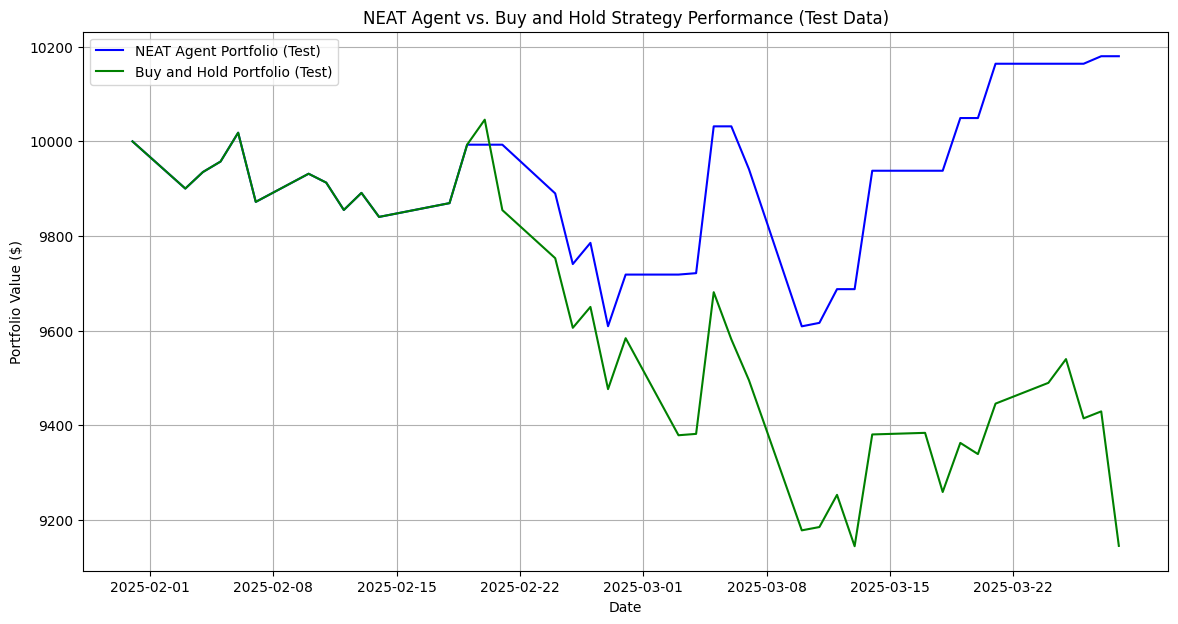

Test data portfolio comparison plot generated.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(portfolio_df_test.index, portfolio_df_test['Portfolio Value'], label='NEAT Agent Portfolio (Test)', color='blue')
plt.plot(buy_and_hold_portfolio_df_test.index, buy_and_hold_portfolio_df_test['Portfolio Value'], label='Buy and Hold Portfolio (Test)', color='green')
plt.title('NEAT Agent vs. Buy and Hold Strategy Performance (Test Data)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Test data portfolio comparison plot generated.")

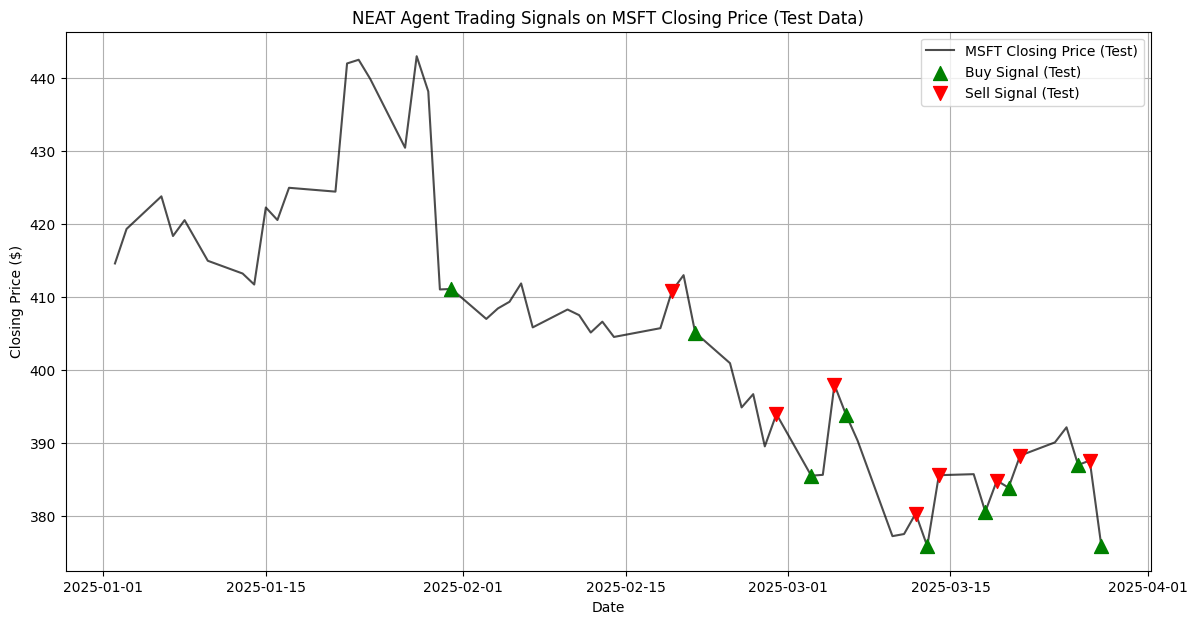

Test data trading signals plot generated.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(msft_data_test.index, msft_data_test[('Close', 'MSFT')], label='MSFT Closing Price (Test)', color='black', alpha=0.7)
plt.scatter(buy_points_df_test.index, buy_points_df_test['Price'], marker='^', color='green', s=100, label='Buy Signal (Test)', zorder=5)
plt.scatter(sell_points_df_test.index, sell_points_df_test['Price'], marker='v', color='red', s=100, label='Sell Signal (Test)', zorder=5)
plt.title('NEAT Agent Trading Signals on MSFT Closing Price (Test Data)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Test data trading signals plot generated.")

In [ ]:
print(winner)

Key: 5400
Fitness: 22375.115402636362
Nodes:
	0 DefaultNodeGene(key=0, bias=2.211436756526032, response=1.0, activation=sigmoid, aggregation=sum)
Connections:
	DefaultConnectionGene(key=(-3, 0), innovation=2142, weight=0.6584230024725981, enabled=True)
	DefaultConnectionGene(key=(-1, 0), innovation=1, weight=-4.5226161447219315, enabled=True)


## Update eval_genomes_trading for shorting

### Subtask:
Modify the `eval_genomes_trading` function to implement short-selling and covering logic. This will enable the NEAT agent to take both long and short positions.


## Update simulate_trading_strategy for shorting

### Subtask:
Apply the same short-selling and covering logic to the `simulate_trading_strategy` function to ensure consistency in performance simulation and visualization.
